## Notebook 07 — Latency & Throughput
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** End-to-end inference latency and theoretical throughput benchmarking for RF and MLP pipelines


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import pickle
import time
from PIL import Image
from scipy.ndimage import gaussian_filter
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import sys
sys.path.insert(0, os.path.abspath('..'))

In [2]:
CLASSES = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']
DATASET_PATH = os.path.join('..', 'datasets', 'dataset-resized')
RESULTS_PATH = os.path.join('..', 'results')
FIGURES_PATH = os.path.join('..', 'results', 'figures')
IMAGE_SIZE = (224, 224)
HISTOGRAM_BINS = 32

In [3]:
with open(os.path.join(RESULTS_PATH, 'rf_final_model.pkl'), 'rb') as f:
    rf_model = pickle.load(f)

with open(os.path.join(RESULTS_PATH, 'mlp_final_model.pkl'), 'rb') as f:
    mlp_model = pickle.load(f)

with open(os.path.join(RESULTS_PATH, 'mlp_scaler.pkl'), 'rb') as f:
    mlp_scaler = pickle.load(f)

In [4]:
# Defines the feature extraction pipeline used as the timed first stage of each inference pipeline

from src.features import extract_features_from_image as extract_features


In [1]:
# Loads one representative image per class to use as samples for latency timing

sample_images = []
sample_labels = []

for class_name in CLASSES:
    class_folder = os.path.join(DATASET_PATH, class_name)
    img_file = sorted(os.listdir(class_folder))[0]
    img_path = os.path.join(class_folder, img_file)
    image = Image.open(img_path).convert('RGB')
    sample_images.append(image)
    sample_labels.append(class_name)

print(f"Loaded {len(sample_images)} sample images for benchmarking")
print("Sample classes:", sample_labels)

Loaded 6 sample images for benchmarking
Sample classes: ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']


In [2]:
# Benchmarks feature extraction latency by averaging over N_REPEATS timed calls per sample image

N_REPEATS = 200

extraction_times = []

for image in sample_images:
    times = []
    for _ in range(N_REPEATS):
        start = time.perf_counter()
        features = extract_features(image)
        end = time.perf_counter()
        times.append(end - start)
    extraction_times.append(np.mean(times))

mean_extraction_ms = np.mean(extraction_times) * 1000
std_extraction_ms  = np.std(extraction_times) * 1000

print(f"Feature extraction latency:")
print(f"  Mean : {mean_extraction_ms:.3f} ms")
print(f"  Std  : {std_extraction_ms:.3f} ms")
print(f"  Min  : {min(extraction_times)*1000:.3f} ms")
print(f"  Max  : {max(extraction_times)*1000:.3f} ms")

Feature extraction latency:
  Mean : 18.152 ms
  Std  : 0.124 ms
  Min  : 17.915 ms
  Max  : 18.339 ms


In [3]:
# Pre-computes feature vectors for all samples, then measures RF and MLP classification latency independently over repeated calls

sample_features = np.array([extract_features(img) for img in sample_images])
sample_features_scaled = mlp_scaler.transform(sample_features)

print(f"Sample features shape: {sample_features.shape}")

rf_times = []
for i in range(len(sample_images)):
    times = []
    feature_vector = sample_features[i].reshape(1, -1)
    for _ in range(N_REPEATS):
        start = time.perf_counter()
        prediction = rf_model.predict(feature_vector)
        end = time.perf_counter()
        times.append(end - start)
    rf_times.append(np.mean(times))

mean_rf_ms = np.mean(rf_times) * 1000
std_rf_ms  = np.std(rf_times) * 1000

print(f"\nRF classification latency:")
print(f"  Mean : {mean_rf_ms:.4f} ms")
print(f"  Std  : {std_rf_ms:.4f} ms")

mlp_times = []
for i in range(len(sample_images)):
    times = []
    feature_vector = sample_features_scaled[i].reshape(1, -1)
    for _ in range(N_REPEATS):
        start = time.perf_counter()
        prediction = mlp_model.predict(feature_vector)
        end = time.perf_counter()
        times.append(end - start)
    mlp_times.append(np.mean(times))

mean_mlp_ms = np.mean(mlp_times) * 1000
std_mlp_ms  = np.std(mlp_times) * 1000

print(f"\nMLP classification latency:")
print(f"  Mean : {mean_mlp_ms:.4f} ms")
print(f"  Std  : {std_mlp_ms:.4f} ms")

Sample features shape: (6, 122)



RF classification latency:
  Mean : 38.9877 ms
  Std  : 1.9884 ms

MLP classification latency:
  Mean : 0.1048 ms
  Std  : 0.0006 ms


In [4]:
# Combines extraction and classification latencies to compute end-to-end pipeline latency, theoretical throughput, and items-per-minute figures

rf_e2e_ms  = mean_extraction_ms + mean_rf_ms
mlp_e2e_ms = mean_extraction_ms + mean_mlp_ms

print("=== End to End Latency ===")
print(f"\nRF pipeline:")
print(f"  Feature extraction : {mean_extraction_ms:.3f} ms")
print(f"  Classification     : {mean_rf_ms:.4f} ms")
print(f"  Total e2e latency  : {rf_e2e_ms:.3f} ms")

print(f"\nMLP pipeline:")
print(f"  Feature extraction : {mean_extraction_ms:.3f} ms")
print(f"  Scaling            : ~0.01 ms (negligible)")
print(f"  Classification     : {mean_mlp_ms:.4f} ms")
print(f"  Total e2e latency  : {mlp_e2e_ms:.3f} ms")

rf_throughput  = 1000 / rf_e2e_ms
mlp_throughput = 1000 / mlp_e2e_ms

print(f"\n=== Theoretical Throughput ===")
print(f"  RF  : {rf_throughput:.2f}  images/second")
print(f"  MLP : {mlp_throughput:.2f} images/second")

rf_ipm  = rf_throughput  * 60
mlp_ipm = mlp_throughput * 60

print(f"\n  RF  : {rf_ipm:.1f}  items/minute")
print(f"  MLP : {mlp_ipm:.1f} items/minute")

import json
latency_results = {
    'feature_extraction_ms': mean_extraction_ms,
    'feature_extraction_std_ms': std_extraction_ms,
    'rf_classification_ms': mean_rf_ms,
    'rf_classification_std_ms': std_rf_ms,
    'mlp_classification_ms': mean_mlp_ms,
    'mlp_classification_std_ms': std_mlp_ms,
    'rf_e2e_ms': rf_e2e_ms,
    'mlp_e2e_ms': mlp_e2e_ms,
    'rf_throughput_per_second': rf_throughput,
    'mlp_throughput_per_second': mlp_throughput,
    'rf_throughput_per_minute': rf_ipm,
    'mlp_throughput_per_minute': mlp_ipm
}

with open(os.path.join(RESULTS_PATH, 'latency_results.json'), 'w') as f:
    json.dump(latency_results, f, indent=2)

print(f"\nLatency results saved.")

=== End to End Latency ===

RF pipeline:
  Feature extraction : 18.152 ms
  Classification     : 38.9877 ms
  Total e2e latency  : 57.140 ms

MLP pipeline:
  Feature extraction : 18.152 ms
  Scaling            : ~0.01 ms (negligible)
  Classification     : 0.1048 ms
  Total e2e latency  : 18.257 ms

=== Theoretical Throughput ===
  RF  : 17.50  images/second
  MLP : 54.77 images/second

  RF  : 1050.1  items/minute
  MLP : 3286.5 items/minute

Latency results saved.


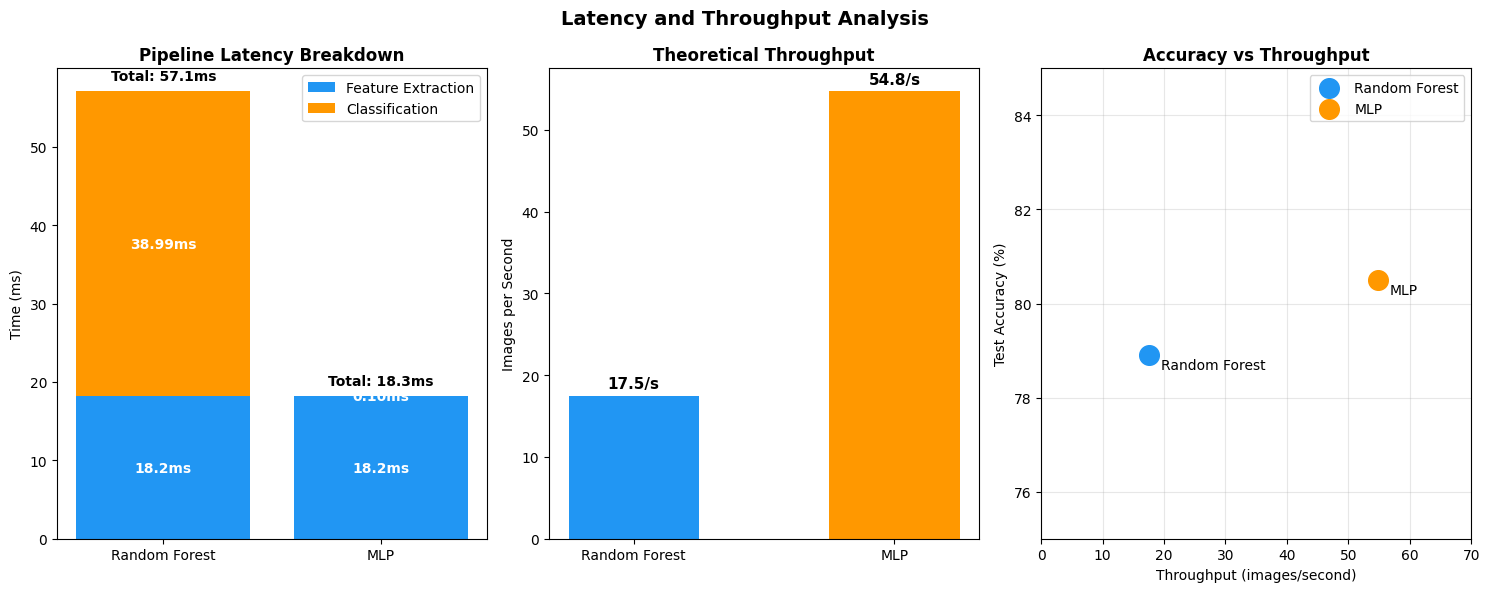

Latency plot saved.


In [5]:
# Three-panel figure: pipeline latency breakdown, throughput comparison, and accuracy-vs-throughput scatter plot

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

categories = ['Random Forest', 'MLP']
extraction_times_plot = [mean_extraction_ms, mean_extraction_ms]
classification_times_plot = [mean_rf_ms, mean_mlp_ms]

bars1 = axes[0].bar(categories, extraction_times_plot,
                    color='#2196F3', label='Feature Extraction')
bars2 = axes[0].bar(categories, classification_times_plot,
                    bottom=extraction_times_plot,
                    color='#FF9800', label='Classification')

axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Pipeline Latency Breakdown', fontweight='bold')
axes[0].legend()

for i, (e, c) in enumerate(zip(extraction_times_plot, classification_times_plot)):
    axes[0].text(i, e/2, f'{e:.1f}ms', ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)
    axes[0].text(i, e + c/2, f'{c:.2f}ms', ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

for i, total in enumerate([rf_e2e_ms, mlp_e2e_ms]):
    axes[0].text(i, total + 1, f'Total: {total:.1f}ms',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

models = ['Random Forest', 'MLP']
throughputs = [rf_throughput, mlp_throughput]
colours = ['#2196F3', '#FF9800']

bars = axes[1].bar(models, throughputs, color=colours, width=0.5)
axes[1].set_ylabel('Images per Second')
axes[1].set_title('Theoretical Throughput', fontweight='bold')

for bar, val in zip(bars, throughputs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}/s', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

axes[2].scatter(rf_throughput, 78.9, s=200, color='#2196F3',
               zorder=5, label='Random Forest')
axes[2].scatter(mlp_throughput, 80.5, s=200, color='#FF9800',
               zorder=5, label='MLP')

axes[2].annotate('Random Forest',
                xy=(rf_throughput, 78.9),
                xytext=(rf_throughput + 2, 78.6),
                fontsize=10)
axes[2].annotate('MLP',
                xy=(mlp_throughput, 80.5),
                xytext=(mlp_throughput + 2, 80.2),
                fontsize=10)

axes[2].set_xlabel('Throughput (images/second)')
axes[2].set_ylabel('Test Accuracy (%)')
axes[2].set_title('Accuracy vs Throughput', fontweight='bold')
axes[2].set_xlim(0, 70)
axes[2].set_ylim(75, 85)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.suptitle('Latency and Throughput Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'latency_throughput.png'), dpi=150)
plt.show()
print("Latency plot saved.")

In [6]:
print(f"\nFeature Extraction:")
print(f"  Mean latency : {mean_extraction_ms:.3f} ms (+/- {std_extraction_ms:.3f} ms)")

print(f"\nClassification Latency:")
print(f"  RF  : {mean_rf_ms:.4f} ms (+/- {std_rf_ms:.4f} ms)")
print(f"  MLP : {mean_mlp_ms:.4f} ms (+/- {std_mlp_ms:.4f} ms)")
print(f"  RF/MLP ratio : {mean_rf_ms/mean_mlp_ms:.1f}x slower")

print(f"\nEnd to End Latency:")
print(f"  RF  : {rf_e2e_ms:.3f} ms")
print(f"  MLP : {mlp_e2e_ms:.3f} ms")
print(f"  RF/MLP ratio : {rf_e2e_ms/mlp_e2e_ms:.2f}x slower")

print(f"\nThroughput:")
print(f"  RF  : {rf_throughput:.2f} images/second | {rf_ipm:.1f} items/minute")
print(f"  MLP : {mlp_throughput:.2f} images/second | {mlp_ipm:.1f} items/minute")


Feature Extraction:
  Mean latency : 18.152 ms (+/- 0.124 ms)

Classification Latency:
  RF  : 38.9877 ms (+/- 1.9884 ms)
  MLP : 0.1048 ms (+/- 0.0006 ms)
  RF/MLP ratio : 372.1x slower

End to End Latency:
  RF  : 57.140 ms
  MLP : 18.257 ms
  RF/MLP ratio : 3.13x slower

Throughput:
  RF  : 17.50 images/second | 1050.1 items/minute
  MLP : 54.77 images/second | 3286.5 items/minute


### Batched throughput

Everything above is single-image and sequential, and the items/min figures are derived as
`1 / latency`. That only holds if the line processes one object at a time and waits for
each result before starting the next. Production sorters do not work that way: frames
arrive continuously and are handed to the classifier in groups, which amortises per-call
overhead over many objects.

That matters here specifically because the `n_jobs` result above is an overhead result.
Parallelising 200 trees loses to a single thread for one 122-feature row because thread
scheduling costs more than the work. If a batch is large enough, the same overhead is paid
once for many rows and the ordering could reverse.

This section measures that. For batch sizes 1, 8, 32 and 128, and for the RF at `n_jobs` in
{1, 2, -1} plus the MLP, feature extraction and classification are timed separately, one
warm-up call per configuration is discarded, and each measurement is the mean of at least
50 timed runs.

In [7]:
import pandas as pd

BATCH_SIZES = [1, 8, 32, 128]
N_JOBS_LIST = [1, 2, -1]
N_BATCH_RUNS = 50          # timed runs per configuration, after one discarded warm-up
TARGET_ITEMS_PER_MIN = 1200

print(f"Logical CPUs available: {os.cpu_count()}")

Logical CPUs available: 16


In [8]:
# Loads a pool of images large enough for the biggest batch, spread evenly across the six
# classes and taken in sorted filename order so the pool is identical on any machine.
# Images are decoded once up front: this benchmark measures the pipeline, not disk I/O.

POOL_SIZE = max(BATCH_SIZES)
per_class = -(-POOL_SIZE // len(CLASSES))   # ceiling division

image_pool = []
for class_name in CLASSES:
    class_folder = os.path.join(DATASET_PATH, class_name)
    filenames = sorted(
        f for f in os.listdir(class_folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    )
    for filename in filenames[:per_class]:
        image_pool.append(
            Image.open(os.path.join(class_folder, filename)).convert('RGB')
        )

image_pool = image_pool[:POOL_SIZE]
pool_features = np.array([extract_features(img) for img in image_pool])
pool_features_scaled = mlp_scaler.transform(pool_features)

print(f"Image pool: {len(image_pool)} images, features {pool_features.shape}")

Image pool: 128 images, features (128, 122)


In [9]:
# Feature extraction is a per-image loop inside src/features.py, so it is identical for every
# classifier configuration and is measured once per batch size rather than once per config.

def time_feature_extraction(batch_size):
    batch = image_pool[:batch_size]

    for image in batch:                      # warm-up, discarded
        extract_features(image)

    times = []
    for _ in range(N_BATCH_RUNS):
        start = time.perf_counter()
        for image in batch:
            extract_features(image)
        times.append(time.perf_counter() - start)

    return np.mean(times) * 1000 / batch_size, np.std(times) * 1000 / batch_size


extraction_per_item = {}

for batch_size in BATCH_SIZES:
    mean_ms, std_ms = time_feature_extraction(batch_size)
    extraction_per_item[batch_size] = mean_ms
    print(f"batch={batch_size:>4}  feature extraction {mean_ms:7.3f} ms/item "
          f"(+/- {std_ms:.3f})")

batch=   1  feature extraction  18.414 ms/item (+/- 0.344)


batch=   8  feature extraction  18.279 ms/item (+/- 0.142)


batch=  32  feature extraction  18.335 ms/item (+/- 0.250)


batch= 128  feature extraction  18.255 ms/item (+/- 0.120)


In [10]:
# Classification timing. rf_model.n_jobs is reassigned in place to switch thread counts, the
# same weights throughout; the pickle on disk is not rewritten. It is restored afterwards.

def time_classification(predict_fn, features, batch_size):
    batch = features[:batch_size]

    predict_fn(batch)                        # warm-up, discarded

    times = []
    for _ in range(N_BATCH_RUNS):
        start = time.perf_counter()
        predict_fn(batch)
        times.append(time.perf_counter() - start)

    return np.mean(times) * 1000 / batch_size, np.std(times) * 1000 / batch_size


rf_n_jobs_original = rf_model.n_jobs
rows = []

for n_jobs in N_JOBS_LIST:
    rf_model.n_jobs = n_jobs
    for batch_size in BATCH_SIZES:
        clf_ms, clf_std = time_classification(rf_model.predict, pool_features, batch_size)
        rows.append({
            'Configuration': f'RF n_jobs={n_jobs}',
            'Batch size': batch_size,
            'Extraction ms/item': extraction_per_item[batch_size],
            'Classification ms/item': clf_ms,
            'Classification std': clf_std,
        })

rf_model.n_jobs = rf_n_jobs_original

# The MLP is timed on pre-scaled features, matching the convention of the single-image cells
# above where scaling was measured as negligible against the 18 ms extraction stage.
for batch_size in BATCH_SIZES:
    clf_ms, clf_std = time_classification(
        mlp_model.predict, pool_features_scaled, batch_size
    )
    rows.append({
        'Configuration': 'MLP',
        'Batch size': batch_size,
        'Extraction ms/item': extraction_per_item[batch_size],
        'Classification ms/item': clf_ms,
        'Classification std': clf_std,
    })

batch_results = pd.DataFrame(rows)
batch_results['Total ms/item'] = (
    batch_results['Extraction ms/item'] + batch_results['Classification ms/item']
)
batch_results['Items/min'] = 60_000 / batch_results['Total ms/item']
batch_results['Meets 1200/min'] = batch_results['Items/min'] >= TARGET_ITEMS_PER_MIN

print(batch_results.round(4).to_string(index=False))

Configuration  Batch size  Extraction ms/item  Classification ms/item  Classification std  Total ms/item  Items/min  Meets 1200/min
  RF n_jobs=1           1             18.4142                  9.3847              0.4344        27.7989  2158.3585            True
  RF n_jobs=1           8             18.2793                  1.2175              0.0424        19.4968  3077.4275            True
  RF n_jobs=1          32             18.3349                  0.3206              0.0062        18.6555  3216.2146            True
  RF n_jobs=1         128             18.2547                  0.0970              0.0023        18.3517  3269.4552            True
  RF n_jobs=2           1             18.4142                 37.5200             14.2080        55.9342  1072.6886           False
  RF n_jobs=2           8             18.2793                  4.0254              0.7556        22.3047  2690.0219            True
  RF n_jobs=2          32             18.3349                  1.1132       

In [11]:
print("=== Per-item amortised latency (ms) and throughput ===\n")
print(f"{'Configuration':<16} {'Batch':>6} {'Extract':>9} {'Classify':>9} "
      f"{'Total':>9} {'Items/min':>11} {'>=1200':>8}")
print("-" * 72)

for _, row in batch_results.iterrows():
    print(f"{row['Configuration']:<16} {int(row['Batch size']):>6} "
          f"{row['Extraction ms/item']:>9.3f} {row['Classification ms/item']:>9.3f} "
          f"{row['Total ms/item']:>9.3f} {row['Items/min']:>11.0f} "
          f"{'yes' if row['Meets 1200/min'] else 'no':>8}")

=== Per-item amortised latency (ms) and throughput ===

Configuration     Batch   Extract  Classify     Total   Items/min   >=1200
------------------------------------------------------------------------
RF n_jobs=1           1    18.414     9.385    27.799        2158      yes
RF n_jobs=1           8    18.279     1.218    19.497        3077      yes
RF n_jobs=1          32    18.335     0.321    18.655        3216      yes
RF n_jobs=1         128    18.255     0.097    18.352        3269      yes
RF n_jobs=2           1    18.414    37.520    55.934        1073       no
RF n_jobs=2           8    18.279     4.025    22.305        2690      yes
RF n_jobs=2          32    18.335     1.113    19.448        3085      yes
RF n_jobs=2         128    18.255     0.374    18.628        3221      yes
RF n_jobs=-1          1    18.414    36.170    54.585        1099       no
RF n_jobs=-1          8    18.279     4.536    22.816        2630      yes
RF n_jobs=-1         32    18.335     1.077   

In [12]:
# The question the single-image result raises: does n_jobs=1 still win once the same thread
# overhead is spread over a whole batch?

clf_pivot = batch_results.pivot(
    index='Batch size', columns='Configuration', values='Classification ms/item'
)
rf_columns = [f'RF n_jobs={j}' for j in N_JOBS_LIST]

print("Classification stage only, ms per item:\n")
print(clf_pivot[rf_columns + ['MLP']].round(4).to_string())

print("\n=== Does the n_jobs=1 advantage survive? ===\n")
print(f"{'Batch':>6} {'Fastest RF config':<20} {'n_jobs=1 ms/item':>18} "
      f"{'best ms/item':>14} {'n_jobs=1 wins':>15}")
print("-" * 78)

survives = {}
for batch_size in BATCH_SIZES:
    row = clf_pivot.loc[batch_size, rf_columns]
    fastest = row.idxmin()
    wins = fastest == 'RF n_jobs=1'
    survives[batch_size] = bool(wins)
    print(f"{batch_size:>6} {fastest:<20} {row['RF n_jobs=1']:>18.4f} "
          f"{row.min():>14.4f} {'yes' if wins else 'no':>15}")

Classification stage only, ms per item:

Configuration  RF n_jobs=1  RF n_jobs=2  RF n_jobs=-1     MLP
Batch size                                                   
1                   9.3847      37.5200       36.1704  0.2394
8                   1.2175       4.0254        4.5365  0.0206
32                  0.3206       1.1132        1.0772  0.0080
128                 0.0970       0.3736        0.3815  0.0045

=== Does the n_jobs=1 advantage survive? ===

 Batch Fastest RF config      n_jobs=1 ms/item   best ms/item   n_jobs=1 wins
------------------------------------------------------------------------------
     1 RF n_jobs=1                      9.3847         9.3847             yes
     8 RF n_jobs=1                      1.2175         1.2175             yes
    32 RF n_jobs=1                      0.3206         0.3206             yes
   128 RF n_jobs=1                      0.0970         0.0970             yes


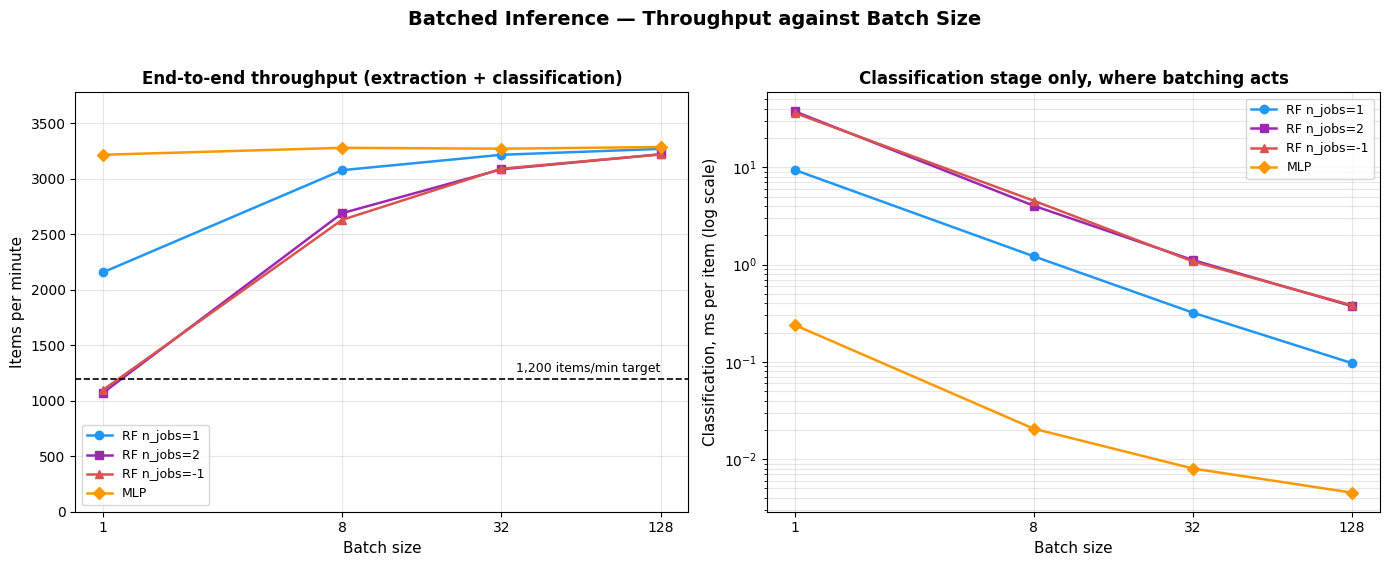

Saved: batch_throughput.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

styles = {
    'RF n_jobs=1':  ('#2196F3', 'o'),
    'RF n_jobs=2':  ('#9C27B0', 's'),
    'RF n_jobs=-1': ('#d9534f', '^'),
    'MLP':          ('#FF9800', 'D'),
}

ax = axes[0]
for config, (colour, marker) in styles.items():
    subset = batch_results[batch_results['Configuration'] == config]
    ax.plot(subset['Batch size'], subset['Items/min'],
            marker=marker, color=colour, label=config, linewidth=1.8)

ax.axhline(TARGET_ITEMS_PER_MIN, color='black', linestyle='--', linewidth=1.2)
ax.text(BATCH_SIZES[-1], TARGET_ITEMS_PER_MIN * 1.03,
        f'{TARGET_ITEMS_PER_MIN:,} items/min target', ha='right', va='bottom', fontsize=9)

ax.set_xscale('log', base=2)
ax.set_xticks(BATCH_SIZES)
ax.set_xticklabels(BATCH_SIZES)
ax.set_xlabel('Batch size', fontsize=11)
ax.set_ylabel('Items per minute', fontsize=11)
ax.set_title('End-to-end throughput (extraction + classification)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(batch_results['Items/min']) * 1.15)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
for config, (colour, marker) in styles.items():
    subset = batch_results[batch_results['Configuration'] == config]
    ax.plot(subset['Batch size'], subset['Classification ms/item'],
            marker=marker, color=colour, label=config, linewidth=1.8)

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xticks(BATCH_SIZES)
ax.set_xticklabels(BATCH_SIZES)
ax.set_xlabel('Batch size', fontsize=11)
ax.set_ylabel('Classification, ms per item (log scale)', fontsize=11)
ax.set_title('Classification stage only, where batching acts',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')

plt.suptitle('Batched Inference \u2014 Throughput against Batch Size',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'batch_throughput.png'), dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: batch_throughput.png")

In [14]:
batch_throughput_results = {
    'batch_sizes': BATCH_SIZES,
    'n_jobs_list': N_JOBS_LIST,
    'n_timed_runs_per_config': N_BATCH_RUNS,
    'warmup_calls_discarded': 1,
    'target_items_per_min': TARGET_ITEMS_PER_MIN,
    'logical_cpus': os.cpu_count(),
    'extraction_ms_per_item': {str(k): float(v) for k, v in extraction_per_item.items()},
    'n_jobs_1_fastest_rf_config': {str(k): v for k, v in survives.items()},
    'measurements': batch_results.drop(columns='Meets 1200/min').to_dict(orient='records'),
}

with open(os.path.join(RESULTS_PATH, 'batch_throughput_results.json'), 'w') as f:
    json.dump(batch_throughput_results, f, indent=2)

batch_results.to_csv(os.path.join(RESULTS_PATH, 'batch_throughput.csv'), index=False)

print("Saved: batch_throughput_results.json")
print("Saved: batch_throughput.csv")

Saved: batch_throughput_results.json
Saved: batch_throughput.csv


In [15]:
# Summary for finding 3 in the README

single = batch_results[batch_results['Batch size'] == 1].set_index('Configuration')
largest = batch_results[batch_results['Batch size'] == max(BATCH_SIZES)].set_index('Configuration')

print("--- README summary ---\n")
print(f"Feature extraction per item: {extraction_per_item[1]:.2f} ms at batch 1, "
      f"{extraction_per_item[max(BATCH_SIZES)]:.2f} ms at batch {max(BATCH_SIZES)} "
      f"({(extraction_per_item[max(BATCH_SIZES)] / extraction_per_item[1] - 1) * 100:+.1f}%).")
print()

for config in styles:
    print(f"{config:<14} classification {single.loc[config, 'Classification ms/item']:8.3f} "
          f"-> {largest.loc[config, 'Classification ms/item']:7.3f} ms/item, "
          f"throughput {single.loc[config, 'Items/min']:6.0f} -> "
          f"{largest.loc[config, 'Items/min']:6.0f} items/min")

print()
reversed_at = [b for b in BATCH_SIZES if not survives[b]]
if reversed_at:
    print(f"The n_jobs=1 advantage does NOT survive at batch sizes: {reversed_at}")
else:
    print("The n_jobs=1 advantage survives at every batch size tested.")

--- README summary ---

Feature extraction per item: 18.41 ms at batch 1, 18.25 ms at batch 128 (-0.9%).

RF n_jobs=1    classification    9.385 ->   0.097 ms/item, throughput   2158 ->   3269 items/min
RF n_jobs=2    classification   37.520 ->   0.374 ms/item, throughput   1073 ->   3221 items/min
RF n_jobs=-1   classification   36.170 ->   0.382 ms/item, throughput   1099 ->   3220 items/min
MLP            classification    0.239 ->   0.005 ms/item, throughput   3217 ->   3286 items/min

The n_jobs=1 advantage survives at every batch size tested.
